# 02 — Embeddings & Vector Store

**Goal:** Embed the ~5,000+ chunks with `text-embedding-3-small` and persist them in a local ChromaDB collection.

**Output:** `vectorstore/` directory (ChromaDB persisted to disk)

**⚠️ API cost:** ~$0.03 USD — run this notebook **once only**.

## 1. Imports & Load Chunks

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.document_processor import load_chunks
from src.vectorstore import get_embeddings, create_vectorstore, load_vectorstore, search

CHUNKS_PATH   = ROOT / 'data' / 'processed' / 'chunks_processed.json'
VECTORSTORE_DIR = str(ROOT / 'vectorstore')

chunks = load_chunks(CHUNKS_PATH)

Loaded 1183 chunks from /Users/nicolaszuleta95/code_nz/financial-rag-assistant/data/processed/chunks_processed.json


## 2. Initialise Embeddings Model

In [2]:
embeddings = get_embeddings()
print('Embedding model: text-embedding-3-small')
print('Dimensions: 1536')

Embedding model: text-embedding-3-small
Dimensions: 1536


## 3. Cost Estimate Before Embedding

**Run this cell before creating the vector store** to confirm the cost is within budget.

In [3]:
import tiktoken

enc = tiktoken.get_encoding('cl100k_base')

total_tokens = sum(len(enc.encode(c['text'])) for c in chunks)
price_per_million = 0.02  # text-embedding-3-small
estimated_cost = (total_tokens / 1_000_000) * price_per_million

print(f'Total chunks     : {len(chunks):,}')
print(f'Total tokens     : {total_tokens:,}')
print(f'Avg tokens/chunk : {total_tokens / len(chunks):.0f}')
print(f'Estimated cost   : ${estimated_cost:.4f} USD')

Total chunks     : 1,183
Total tokens     : 627,640
Avg tokens/chunk : 531
Estimated cost   : $0.0126 USD


## 4. Create ChromaDB Collection

**⚠️ This cell calls the OpenAI API — run only once.**

If `vectorstore/` already exists with the correct number of documents, skip this cell and go to section 5.

In [4]:
vectorstore = create_vectorstore(chunks, persist_dir=VECTORSTORE_DIR)
print('\nVector store created successfully ✅')

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


  Ingested 200/1183 chunks…
  Ingested 300/1183 chunks…
  Ingested 400/1183 chunks…
  Ingested 500/1183 chunks…
  Ingested 600/1183 chunks…
  Ingested 700/1183 chunks…
  Ingested 800/1183 chunks…
  Ingested 900/1183 chunks…
  Ingested 1000/1183 chunks…
  Ingested 1100/1183 chunks…
  Ingested 1183/1183 chunks…
Created vectorstore with 1183 documents → /Users/nicolaszuleta95/code_nz/financial-rag-assistant/vectorstore/

Vector store created successfully ✅


## 5. Verify Ingestion

In [5]:
# Load from disk to confirm persistence
vs = load_vectorstore(VECTORSTORE_DIR)
count = vs._collection.count()
print(f'Documents in collection: {count:,}')
assert count == len(chunks), f'Expected {len(chunks)} but got {count}'
print('Count matches chunk list ✅')

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Loaded vectorstore — 1183 documents from /Users/nicolaszuleta95/code_nz/financial-rag-assistant/vectorstore/
Documents in collection: 1,183
Count matches chunk list ✅


## 6. Semantic Search Tests

In [6]:
test_queries = [
    "What was JPMorgan's net revenue in 2023?",
    "Risk factors related to interest rates",
    "Digital transformation strategy",
    "Capital requirements Basel III",
    "Credit loss provisions consumer loans",
]

for query in test_queries:
    results = search(vs, query, k=2)
    print(f'\nQ: {query}')
    for doc in results:
        bank = doc.metadata.get('bank', '?')
        page = doc.metadata.get('page', '?')
        snippet = doc.page_content[:120].replace('\n', ' ')
        print(f'  [{bank} p.{page}] {snippet}...')

Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given



Q: What was JPMorgan's net revenue in 2023?
  [JPMorgan Chase p.203] jpm-20231231 18/05/26, 1:12 p.m. 2023 compared with 2022 Net income was $5.2 billion, up 20%. Net revenue was $19.8 bill...
  [JPMorgan Chase p.135] jpm-20231231 18/05/26, 1:12 p.m. This executive overview of the MD&A highlights selected information and does not contai...

Q: Risk factors related to interest rates
  [Bank of America p.25] policy, which has contributed and may continue to contribute to elevated financial and capital market volatility and sig...
  [Bank of America p.25] bac-20231231 18/05/26, 1:14 p.m. requirements and affect our liquidity. Any sudden or prolonged market downturn, as a re...

Q: Digital transformation strategy
  [Bank of America p.46] bac-20231231 18/05/26, 1:14 p.m. rapidly, including from emerging technologies, such as AI, machine learning and quantum...
  [Bank of America p.43] bac-20231231 18/05/26, 1:14 p.m. disruptions to our critical business operations and customer services are

## 7. PCA 2D Visualisation of Embeddings

Colour by bank to check whether the embedding space separates documents by institution (expected: partial separation since all documents are financial in nature).

Generating embeddings for PCA visualisation...


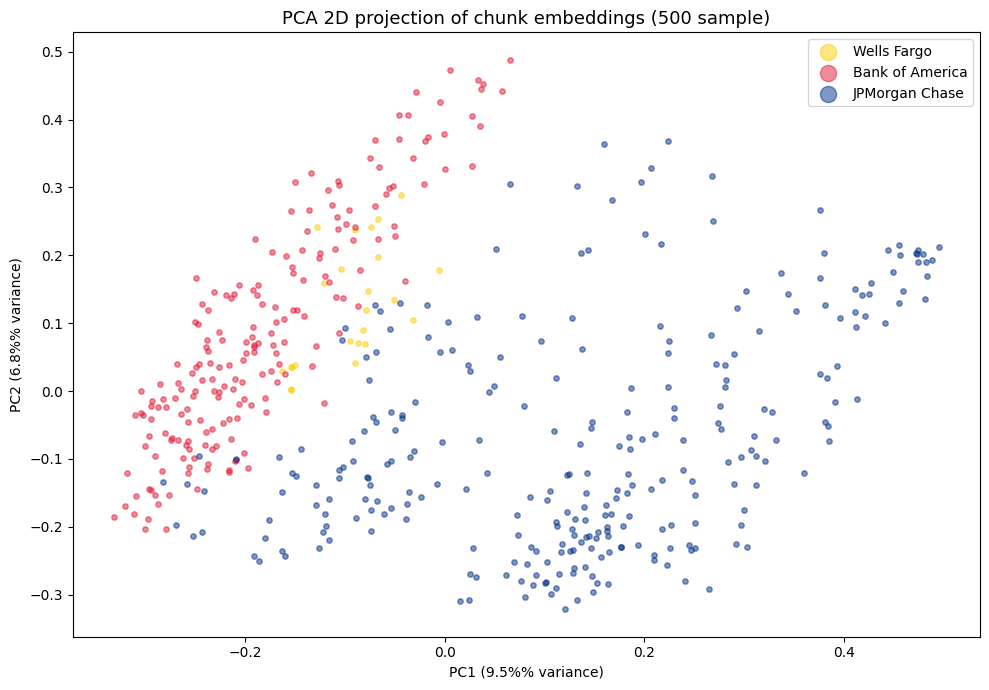

In [7]:
import random

# Sample 500 chunks for visualisation
random.seed(42)
sample_chunks = random.sample(chunks, min(500, len(chunks)))
sample_texts = [c['text'] for c in sample_chunks]
sample_banks = [c['bank'] for c in sample_chunks]

print('Generating embeddings for PCA visualisation...')
sample_vectors = embeddings.embed_documents(sample_texts)

X = np.array(sample_vectors)
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

colors = {'JPMorgan Chase': '#003087', 'Bank of America': '#E31837', 'Wells Fargo': '#FFCD00'}
fig, ax = plt.subplots(figsize=(10, 7))
for bank in set(sample_banks):
    mask = [b == bank for b in sample_banks]
    xs = X_2d[mask, 0]
    ys = X_2d[mask, 1]
    ax.scatter(xs, ys, label=bank, alpha=0.5, s=15, color=colors.get(bank, 'grey'))

ax.set_title('PCA 2D projection of chunk embeddings (500 sample)', fontsize=13)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%% variance)')
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

## 8. Persistence Verification

Close and reload the collection from disk to confirm that the vector store survives a restart.

In [8]:
del vs  # release the current reference

vs_reloaded = load_vectorstore(VECTORSTORE_DIR)
count_after = vs_reloaded._collection.count()
print(f'Documents after reload: {count_after:,}')
assert count_after == len(chunks)
print('Persistence verified ✅')
print(f'\nReady for notebook 03 — vector store at: {VECTORSTORE_DIR}/')

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Loaded vectorstore — 1183 documents from /Users/nicolaszuleta95/code_nz/financial-rag-assistant/vectorstore/
Documents after reload: 1,183
Persistence verified ✅

Ready for notebook 03 — vector store at: /Users/nicolaszuleta95/code_nz/financial-rag-assistant/vectorstore/
